Calculate distances between all pairs of species

In [3]:
from Bio import Phylo
import numpy as np
#from scipy.spatial.distance import pdist, squareform

# Load phylogenetic tree
tree = Phylo.read(r"..\..\input\aligned_caffeine_tree.nwk", "newick")


# Extract terminal node names (species)
terminals = tree.get_terminals()
n = len(terminals)

# Initialize an empty distance matrix
phylo_distances = np.zeros((n, n))

# Compute pairwise distances
for i, sp1 in enumerate(terminals):
    for j, sp2 in enumerate(terminals):
        phylo_distances[i, j] = tree.distance(sp1, sp2)

# Optionally, print or convert the matrix to a DataFrame for better readability
import pandas as pd
species_names = [str(sp) for sp in terminals]
phylo_df = pd.DataFrame(phylo_distances, index=species_names, columns=species_names)
print(phylo_df)


                         C_bertrandii_A5  C_richardii_A575  \
C_bertrandii_A5                  0.00000           0.11234   
C_richardii_A575                 0.11234           0.00000   
C_farafanganensis_A208           0.12168           0.10018   
C_abbayesii_A601                 0.10538           0.08388   
C_millotii_A222                  0.11130           0.08980   
C_dolichophylla_A206             0.10885           0.08735   
C_ambodirianensis_A572           0.11243           0.09093   
C_homollei_A945                  0.11294           0.09846   
C_perrieri_A12                   0.12485           0.11037   
C_leroyi_A315                    0.11298           0.09850   
C_andrambovatensis_A310          0.13014           0.11566   
C_vianneyi_A946                  0.12294           0.10846   
C_resinosa_A8                    0.13048           0.11600   
C_arenesiana_A403                0.13797           0.12349   
C_kianjavatensis_A602            0.13772           0.12324   
C_vatova

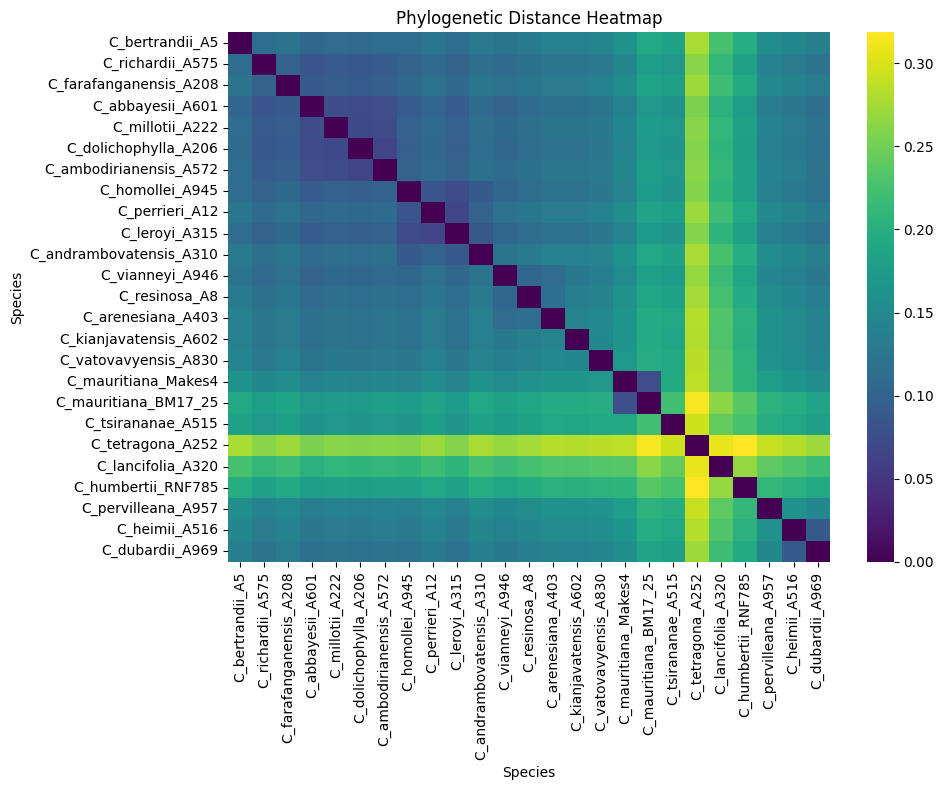

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(phylo_df, cmap="viridis", annot=False, xticklabels=True, yticklabels=True)
plt.title("Phylogenetic Distance Heatmap")
plt.xlabel("Species")
plt.ylabel("Species")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


C:\Users\adm1\AppData\Local\Temp\ipykernel_114300\258011153.py:4: ClusterWarning: The symmetric non-negative hollow observation matrix looks suspiciously like an uncondensed distance matrix
  linkage_matrix = linkage(phylo_distances, method="ward")


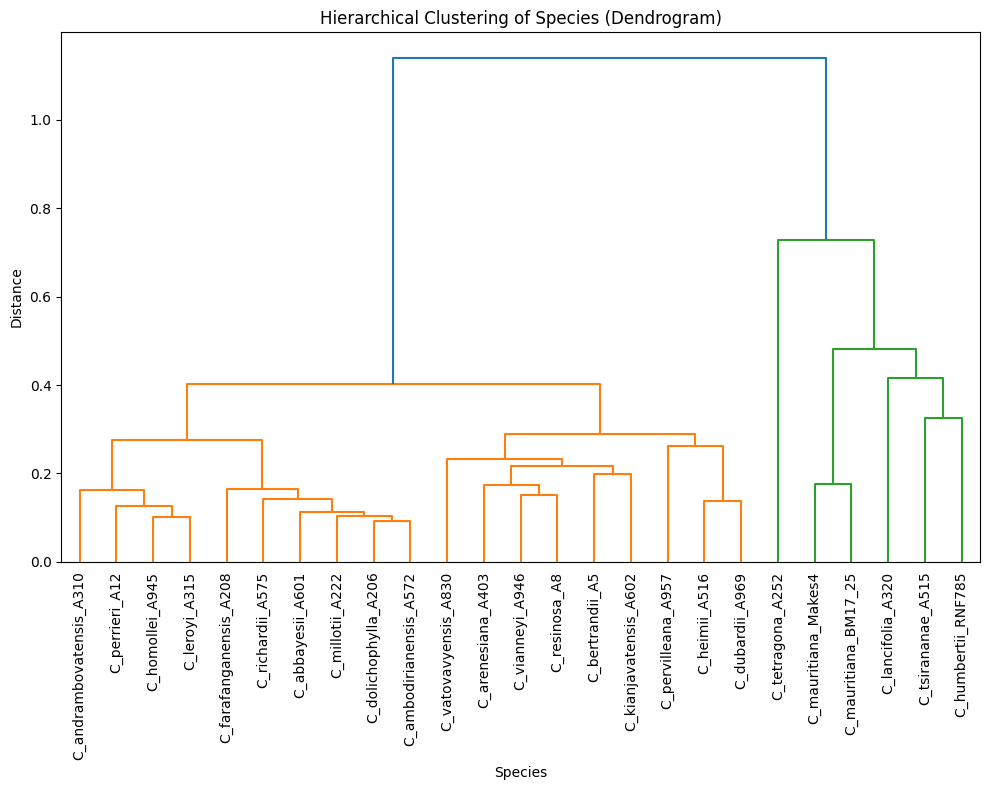

In [6]:
from scipy.cluster.hierarchy import dendrogram, linkage

# Perform hierarchical clustering
linkage_matrix = linkage(phylo_distances, method="ward")

# Plot dendrogram
plt.figure(figsize=(10, 8))
dendrogram(linkage_matrix, labels=species_names, leaf_rotation=90, leaf_font_size=10)
plt.title("Hierarchical Clustering of Species (Dendrogram)")
plt.xlabel("Species")
plt.ylabel("Distance")
plt.tight_layout()
plt.show()


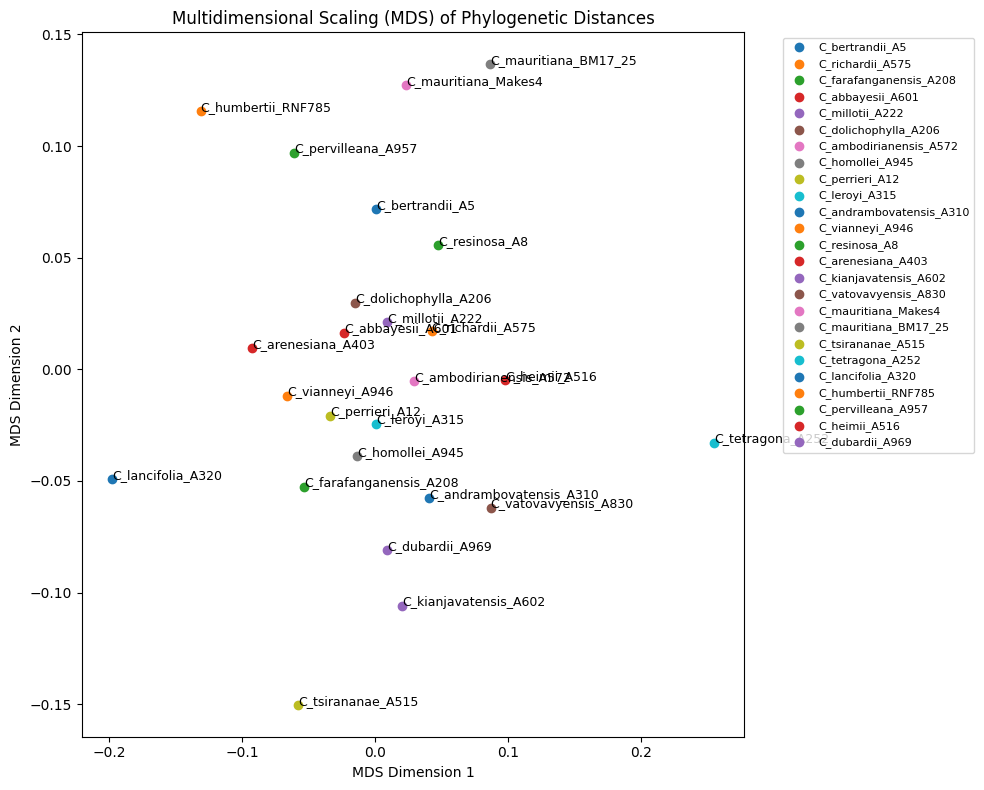

In [7]:
from sklearn.manifold import MDS

# Perform MDS to reduce distances to 2D
mds = MDS(n_components=2, dissimilarity="precomputed", random_state=42)
coords = mds.fit_transform(phylo_distances)

# Plot the MDS results
plt.figure(figsize=(10, 8))
for i, species in enumerate(species_names):
    plt.scatter(coords[i, 0], coords[i, 1], label=species)
    plt.text(coords[i, 0], coords[i, 1], species, fontsize=9)

plt.title("Multidimensional Scaling (MDS) of Phylogenetic Distances")
plt.xlabel("MDS Dimension 1")
plt.ylabel("MDS Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()


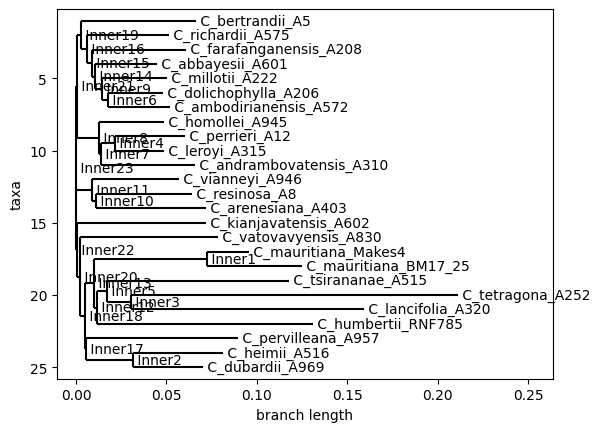

In [4]:
from Bio import Phylo

# Draw the tree
Phylo.draw(tree)


Calculate geographic distances between species locations

In [12]:
import pandas as pd
import numpy as np
from geopy.distance import geodesic  # For Haversine-based distances

# Load CSV file
geo_df = pd.read_csv(r"..\data\gbif_mada_available_caff_content_formatted.csv")  # Replace with your file name
print(geo_df.head())  # Check the format of the loaded data




          specimen_id  longitude   latitude
0  C_humbertii_RNF785  43.797500 -22.875000
1         C_boinensis  46.801111 -16.319444
2         C_bissetiae  46.805278 -16.328889
3         C_bissetiae  46.432222 -15.588889
4         C_bissetiae  46.801111 -16.319444


Only one  geolocation point per species is necessary to calculate mantel test. Exercise to be done with median, mean, hand-picked


In [14]:
# Group by species and calculate median coordinates
median_coords = geo_df.groupby('specimen_id')[['longitude', 'latitude']].median().reset_index()
print(median_coords)


               specimen_id  longitude   latitude
0         C_abbayesii_A601  47.136667 -24.796389
1      C_ankaranensis_A525  48.629095 -16.801293
2        C_arenesiana_A403  47.896430 -19.029844
3        C_augagneuri_A966  47.863972 -21.382389
4          C_bertrandii_A5  46.674722 -25.122222
5              C_bissetiae  46.800000 -16.319444
6              C_boinensis  46.800000 -16.300000
7        C_boiviniana_A980  49.246820 -13.208889
8          C_bonnieri_A535  48.086940 -13.750000
9          C_dubardii_A969  49.166670 -12.578889
10  C_farafanganensis_A208  47.863972 -21.382500
11           C_heimii_A516  49.353050 -12.396327
12         C_homollei_A945  48.731110 -17.503889
13      C_humbertii_RNF785  44.136600 -23.078725
14         C_jumellei_A974  49.173610 -13.274722
15   C_kianjavatensis_A602  47.858610 -21.380280
16       C_labatii_APD3096  44.700833 -18.689444
17       C_lancifolia_A320  47.863972 -21.382389
18           C_leroyi_A315  49.285830 -14.336660
19         C_liaudii

KeyError: "['C_dolichophylla_A206', 'C_ambodirianensis_A572', 'C_andrambovatensis_A310', 'C_vatovavyensis_A830', 'C_mauritiana_Makes4', 'C_mauritiana_BM17_25'] not in index"

In [17]:
# Get species that are present in both phylo_df and median_coords
common_species = [species for species in species_names if species in median_coords['specimen_id'].values]

# Filter median_coords to only include rows with these species
aligned_coords = median_coords[median_coords['specimen_id'].isin(common_species)]

# Reorder aligned_coords to match the order of common_species
aligned_coords = aligned_coords.set_index('specimen_id').loc[common_species].reset_index()

# Verify alignment
print("Aligned Coordinates:")
print(aligned_coords)

# Ensure phylo_df and aligned_coords are in the same order
assert list(aligned_coords['specimen_id']) == common_species, "Alignment mismatch!"


Aligned Coordinates:
               specimen_id  longitude   latitude
0          C_bertrandii_A5  46.674722 -25.122222
1         C_richardii_A575  49.340278 -17.913889
2   C_farafanganensis_A208  47.863972 -21.382500
3         C_abbayesii_A601  47.136667 -24.796389
4          C_millotii_A222  48.318880 -19.014028
5          C_homollei_A945  48.731110 -17.503889
6           C_perrieri_A12  44.561944 -22.712917
7            C_leroyi_A315  49.285830 -14.336660
8          C_vianneyi_A946  47.865916 -21.380139
9            C_resinosa_A8  48.482222 -20.801944
10       C_arenesiana_A403  47.896430 -19.029844
11   C_kianjavatensis_A602  47.858610 -21.380280
12       C_tsirananae_A515  49.322797 -12.323889
13        C_tetragona_A252  47.865736 -18.032802
14       C_lancifolia_A320  47.863972 -21.382389
15      C_humbertii_RNF785  44.136600 -23.078725
16      C_pervilleana_A957  44.561389 -18.033559
17           C_heimii_A516  49.353050 -12.396327
18         C_dubardii_A969  49.166670 -12.578889

In [18]:
# Filter phylo_df to keep only rows/columns corresponding to species in common_species
phylo_df_filtered = phylo_df.loc[common_species, common_species]

# Ensure both phylo_df_filtered and aligned_coords are in the same order
aligned_coords = aligned_coords.set_index('specimen_id').loc[common_species].reset_index()

# Verify the alignment
assert list(aligned_coords['specimen_id']) == list(phylo_df_filtered.index), "Alignment mismatch between phylo_df and coordinates!"


In [19]:
# Prepare coordinates without aggregation
geo_coords = aligned_coords[['specimen_id', 'latitude', 'longitude']]

# Initialize an empty dataframe for distances
row_indices = geo_coords.index
geo_distances = pd.DataFrame(index=row_indices, columns=row_indices, dtype=float)

# Calculate pairwise distances
for i in row_indices:
    for j in row_indices:
        if i == j:
            geo_distances.loc[i, j] = 0
        elif pd.isna(geo_distances.loc[i, j]):
            coord1 = tuple(geo_coords.loc[i, ['latitude', 'longitude']])
            coord2 = tuple(geo_coords.loc[j, ['latitude', 'longitude']])
            distance = geodesic(coord1, coord2).kilometers
            geo_distances.loc[i, j] = distance
            geo_distances.loc[j, i] = distance

# Save or display results
print(geo_distances.head())
geo_distances.to_csv("geographic_distances_full.csv")


           0           1           2           3           4           5   \
0    0.000000  844.483336  431.665935   58.981495  697.306246  870.027160   
1  844.483336    0.000000  414.004864  795.529645  162.685161   78.960179   
2  431.665935  414.004864    0.000000  385.342872  266.481097  438.898273   
3   58.981495  795.529645  385.342872    0.000000  651.813762  824.202445   
4  697.306246  162.685161  266.481097  651.813762    0.000000  172.738014   

           6            7           8           9           10          11  \
0  342.740069  1224.843992  431.973125  513.071337  686.287268  431.747850   
1  728.761771   395.900015  413.686624  332.162000  196.244943  413.987981   
2  371.316791   794.237234    0.330154   90.875835  260.477554    0.607966   
3  349.468010  1179.579163  385.638011  463.409815  643.329839  385.478411   
4  566.109886   527.795767  266.187732  198.665593   44.509160  266.339932   

            12          13          14          15          16      

Performing Mantel test

In [26]:
from skbio.stats.distance import mantel
from skbio.stats.distance import DistanceMatrix

# Convert distance matrices to skbio DistanceMatrix objects
phylo_matrix = DistanceMatrix(phylo_df_filtered, ids=species)
geo_matrix = DistanceMatrix(geo_distances, ids=species)

# Perform the Mantel test
mantel_stat, p_value, _ = mantel(phylo_matrix, geo_matrix, method='pearson', permutations=999)

print(f"Mantel Statistic (r): {mantel_stat}")
print(f"P-value: {p_value}")


ModuleNotFoundError: No module named 'skbio'

In [35]:
import numpy as np
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr

def mantel_test(matrix1, matrix2, permutations=999):
    """
    Perform Mantel test between two distance matrices.
    
    Args:
        matrix1 (np.ndarray): First distance matrix (square-form).
        matrix2 (np.ndarray): Second distance matrix (square-form).
        permutations (int): Number of permutations for significance testing.
    
    Returns:
        r (float): Mantel correlation coefficient.
        p-value (float): p-value from permutation test.
    """
    # Flatten the upper triangle of each matrix
    indices = np.triu_indices_from(matrix1, k=1)
    dist1 = matrix1[indices]
    dist2 = matrix2[indices]

    # Calculate Mantel correlation (Pearson's r)
    r, _ = pearsonr(dist1, dist2)

    # Perform permutations
    permuted_rs = []
    for _ in range(permutations):
        np.random.shuffle(dist2)
        permuted_r, _ = pearsonr(dist1, dist2)
        permuted_rs.append(permuted_r)

    # Calculate p-value
    permuted_rs = np.array(permuted_rs)
    p_value = np.sum(permuted_rs >= r) / permutations

    return r, p_value

# Example usage
phylo_matrix = phylo_df_filtered.to_numpy()  # Replace with your phylogenetic distance matrix
geo_matrix = geo_distances.to_numpy()   # Replace with your geographic distance matrix
r, p = mantel_test(phylo_matrix, geo_matrix)
print(f"r: {r}, p-value: {p}")


r: -0.02523114283621311, p-value: 0.6286286286286287


In [ ]:
import matplotlib.pyplot as plt

# Flatten matrices for scatterplot
phylo_dist_flat = pd_matrix[np.triu_indices(len(species), k=1)]
geo_dist_flat = geo_distances[np.triu_indices(len(species), k=1)]

# Plot
plt.scatter(geo_dist_flat, phylo_dist_flat, alpha=0.7)
plt.xlabel("Geographic Distance (km)")
plt.ylabel("Phylogenetic Distance")
plt.title("Correlation Between Geographic and Phylogenetic Distances")
plt.show()
